# Konwolucyjne sieci neuronowe

Zadanie na te ćwiczenia to implementacja funkcji konwolucji oraz max pooling dla obrazów.

In [1]:
# ploting
%matplotlib inline
# imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from torchvision.datasets import CIFAR10
from torchvision.transforms import Normalize, ToTensor, Compose

100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


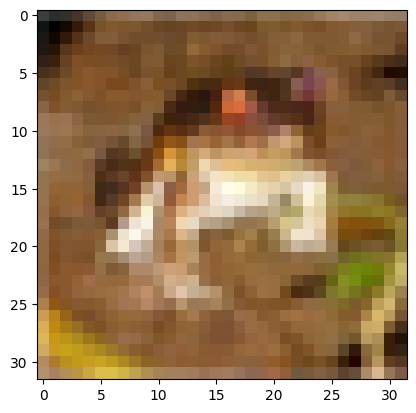

In [2]:
# data loading
# cifar_sample = np.load('resources/cifar_sample.npy')
# # get a first random image

ds = CIFAR10(root=".", download=True, train=True, transform=Compose([ToTensor()]))

np_image = ds[0][0].numpy()
# this should plot a blurry frog
plt.imshow(np_image.transpose(1,2,0))



### Wzory na rozmiary
**Pytanie 1**: Jaki będzie rozmiar obrazka na wyjściu konwolucji/poolingu przy parametrach poniżej.  
**Uwaga**: zarówno we wzorach jak i w kodzie używana jest torchowa konwencja *channel first*.

Stride: $ \hspace{95px} S $  
Padding: $ \hspace{80px} P $  
Obrazek wejściowy: $ \hspace{12px} C_i \times H_i \times W_i$  
Filtry: $ \hspace{100px} K \times C_f \times F \times F $  

Gdzie: $C_i$ to liczba kanału obrazu wejściowego, $H_i, W_i$ to odpowiednio wysokość i szerokość obrazu wejściowego. $K$ to liczba filtrów, $C_f$ liczba kanałów w każdym filtrze, $F$ to zarówno wysokość jak i szerokość filtra (rozważamy tylko filtry kwadratowe).

Obrazek wyjściowy: $ \hspace{15px} C_o \times H_o \times W_o $  


$ \hspace{140px} C_o = \text{???} $  

$ \hspace{140px} H_o = \text{???} $  

$ \hspace{140px} W_o = \text{???} $  

**Pytanie 2**: Ile wag (floatów) ma taka warstwa konwolucyja?   


### Wizualna pomoc do konwolucji
[Opis i wizualizacje](http://cs231n.github.io/convolutional-networks/)


### Zadanie 1:  Konwolucja
Zadaniem jest zaimplementowanie funkcji konwolucji i poolingu dla obrazka 2D. Implementacja nie musi być optymalna pod względem złożoności czasowej (tzn. można/zaleca się używać pętli).

Warunkiem zaliczenia zadania jest przejście komórek testowych dla konwolucji i poolingu. W razie problemów polecam zacząć od poolingu, który jest podobny do konwolucji, ale mniej skomplikowany.

In [3]:
def convolution(image: torch.tensor,
                filters: torch.tensor,
                bias: torch.tensor,
                stride: int = 1,
                padding: int = 1):
    # wymiary
    img_channels, img_height, img_width = image.shape
    n_filters, filter_channels, filter_size, _ = filters.shape

    if padding > 0:
        image_padded = torch.zeros((img_channels, img_height + 2 * padding, img_width + 2 * padding))
        image_padded[:, padding:-padding, padding:-padding] = image
    else:
        image_padded = image

    # wymiary wyjscia
    out_height = (img_height + 2 * padding - filter_size) // stride + 1
    out_width = (img_width + 2 * padding - filter_size) // stride + 1
    out_channels = n_filters


    output = torch.zeros((out_channels, out_height, out_width))

    # konwolucja
    for k in range(n_filters):
        for i in range(out_height):
            for j in range(out_width):
                # fragment
                h_start = i * stride
                h_end = h_start + filter_size
                w_start = j * stride
                w_end = w_start + filter_size

                window = image_padded[:, h_start:h_end, w_start:w_end]

                # splot
                output[k, i, j] = torch.sum(window * filters[k]) + bias[k]

    return output

In [4]:

# cast the frog to tensor
image = torch.tensor(np_image)
# preapre parameters for testing
paddings = [0, 1, 2, 3]
strides = [1, 2, 3, 4]
filters = [(torch.randn((2,3,3,3)), torch.randn((2))),
           (torch.randn((2,3,5,5)), torch.randn((2))),
           (torch.randn((5,3,1,1)), torch.randn((5)))]

# test all combinations
for (filt, bias), stride, padding in product(filters, strides, paddings):
    # your convolution
    out = convolution(image, filt, bias, stride=stride, padding=padding)
    # PyTorch equivalent
    out_torch = torch.conv2d(input=image.unsqueeze(0), weight=filt, bias=bias, padding=padding, stride=stride)
    # asserts
    assert out_torch.squeeze().shape == out.shape
    assert torch.allclose(out, out_torch.squeeze(), atol=1e-5, rtol=1e-5)

### Zadanie 2. Max Pooling
Operacja *max pooling* jest analogiczna do zwykłej konwolucji, lecz zamiast operacji mnożenia z zadanym filtrem na każdym fragmencie wejścia wykonywana jest funkcja *max*.

In [5]:
def max_pooling(image: torch.tensor,
                kernel_size: int,
                stride: int = 1,
                padding: int = 1):
    img_channels, img_height, img_width = image.shape

    if padding > 0:
        image_padded = torch.full((img_channels, img_height + 2 * padding, img_width + 2 * padding), -float('inf'))
        image_padded[:, padding:-padding, padding:-padding] = image
    else:
        image_padded = image

    out_height = (img_height + 2 * padding - kernel_size) // stride + 1
    out_width = (img_width + 2 * padding - kernel_size) // stride + 1
    out_channels = img_channels

    output = torch.zeros((out_channels, out_height, out_width))

    for c in range(out_channels):
        for i in range(out_height):
            for j in range(out_width):
                h_start = i * stride
                h_end = h_start + kernel_size
                w_start = j * stride
                w_end = w_start + kernel_size

                window = image_padded[c, h_start:h_end, w_start:w_end]
                output[c, i, j] = torch.max(window)

    return output

In [6]:
# Max Pooling Test
from itertools import product

# cast the frog to tensor
image = torch.tensor(np_image)
# preapre parameters for testing
kernel_sizes = [2, 3, 4]
paddings = [0, 1]
strides = [1, 2, 3, 4]

# test all combinations
for kernel_size, stride, padding in product(kernel_sizes, strides, paddings):
    # your pooling
    out = max_pooling(image, kernel_size=kernel_size, stride=stride, padding=padding)
    # PyTorch equivalent
    out_torch = torch.nn.functional.max_pool2d(input=image.unsqueeze(0), kernel_size=kernel_size, padding=padding, stride=stride)
    # asserts
    assert out_torch.squeeze().shape == out.shape
    assert torch.allclose(out, out_torch.squeeze(), atol=1e-5, rtol=1e-5)

### Zadanie 3. Trening na CIFAR10

Korzystajac z poznanych dziś konwolucji, a także mechanizmów z poprzednich laboratoriów (ReLU, BatchNorm, Dropout itd), zaprojektuj 4-warstwową sieć konwolucyjną, która posłuży do klasyfikacji zbioru CIFAR-10. Można korzystać z dowolnych technik, z wyjątkiem używania jakichkolwiek pretrenowanych oraz predefiniowanych architektur sieci.

Napisz pętlę uczenia, rozrysuj krzywe loss i accuracy na zbiorach treningowych i testowych. Warunkiem zaliczenia tej części ćwiczenia jest osignięcie minimum 75% accuracy na zbiorze testowym.

100%|██████████| 170M/170M [00:02<00:00, 57.9MB/s]


Epoch 1/20, Loss: 1.4895, Test Acc: 62.12%
Epoch 2/20, Loss: 1.0365, Test Acc: 68.58%
Epoch 3/20, Loss: 0.8694, Test Acc: 73.99%
Epoch 4/20, Loss: 0.7755, Test Acc: 75.22%
Epoch 5/20, Loss: 0.7021, Test Acc: 74.52%
Epoch 6/20, Loss: 0.6447, Test Acc: 78.33%
Epoch 7/20, Loss: 0.6041, Test Acc: 79.09%
Epoch 8/20, Loss: 0.5575, Test Acc: 79.34%
Epoch 9/20, Loss: 0.5289, Test Acc: 80.82%
Epoch 10/20, Loss: 0.4989, Test Acc: 81.71%
Epoch 11/20, Loss: 0.4733, Test Acc: 81.98%
Epoch 12/20, Loss: 0.4489, Test Acc: 82.50%
Epoch 13/20, Loss: 0.4269, Test Acc: 84.27%
Epoch 14/20, Loss: 0.4069, Test Acc: 82.22%
Epoch 15/20, Loss: 0.3836, Test Acc: 84.16%
Epoch 16/20, Loss: 0.3626, Test Acc: 84.94%
Epoch 17/20, Loss: 0.3504, Test Acc: 82.54%
Epoch 18/20, Loss: 0.3353, Test Acc: 84.96%
Epoch 19/20, Loss: 0.3196, Test Acc: 85.07%
Epoch 20/20, Loss: 0.3074, Test Acc: 86.50%


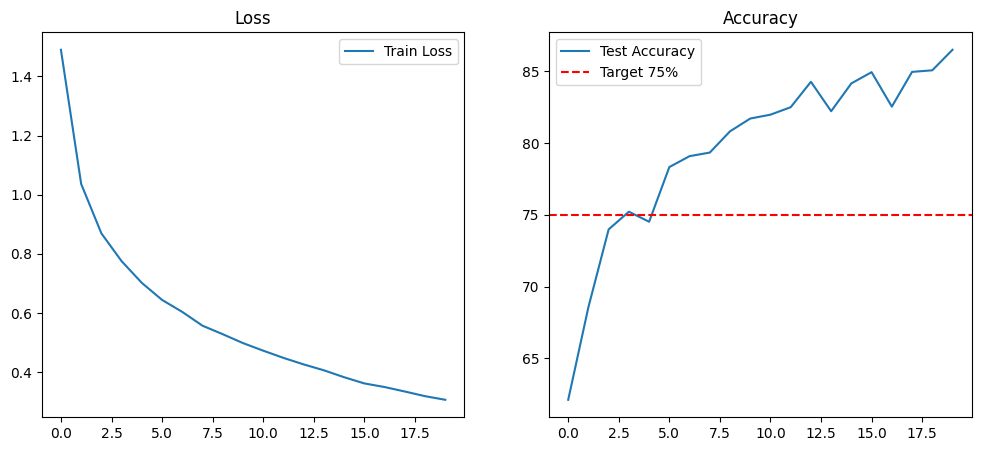

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# dane + augmentacja
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False)


class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(256 * 4 * 4, 10)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)

        x = x.view(-1, 256 * 4 * 4)
        x = self.dropout(x)
        x = self.fc(x)
        return x

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
history = {'train_loss': [], 'test_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    history['train_loss'].append(running_loss / len(trainloader))
    history['test_acc'].append(acc)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(trainloader):.4f}, Test Acc: {acc:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['test_acc'], label='Test Accuracy')
plt.axhline(y=75, color='r', linestyle='--', label='Target 75%')
plt.title('Accuracy')
plt.legend()
plt.show()